<a href="https://colab.research.google.com/github/jiwonojo/Data-Capstone-Design---2026/blob/main/Feature_Importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Read Data

In [ ]:
df=pd.read_csv ('/content/synthetic_fraud_dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
import pandas as pd
import numpy as np

# 1. 데이터 로드 및 시계열 정렬 (가장 중요: 과거->현재 순으로 정렬)
df = pd.read_csv('synthetic_fraud_dataset.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(by=['User_ID', 'Timestamp']).reset_index(drop=True)

# ==============================================================================
# 💡 1. 물리적 이동 불가 속도 (Velocity / Impossible Travel)
# 개념: 직전 결제 위치와 현재 결제 위치가 다른데, 시간 차이가 비행기보다 빠르다면? 무조건 사기!
# ==============================================================================

# 유저별 '직전' 결제 시간과 '직전' 결제 위치 가져오기 (shift 1 적용)
df['Prev_Timestamp'] = df.groupby('User_ID')['Timestamp'].shift(1)
df['Prev_Location'] = df.groupby('User_ID')['Location'].shift(1)

# 직전 결제와의 시간 차이 계산 (시간 단위, Hours)
df['Time_Diff_Hours'] = (df['Timestamp'] - df['Prev_Timestamp']).dt.total_seconds() / 3600.0

# 🚩 물리적 이동 불가 플래그 생성:
# 직전 결제와 위치가 다르고(Location Change), 시간 차이가 2시간 미만일 경우 1 (사기 의심)
df['Impossible_Travel_Flag'] = np.where(
    (df['Location'] != df['Prev_Location']) &
    (df['Prev_Location'].notnull()) &
    (df['Time_Diff_Hours'] < 2.0),
    1, 0
)


# ==============================================================================
# 💡 2. 개인별 활동 이탈도 (Individual Behavioral Deviation)
# 개념: 전체 평균이 아니라, "해당 유저의 과거 평소 씀씀이" 대비 얼마나 크게 결제했는가?
# ==============================================================================

# 누수 방지: 현재 시점 '이전'까지의 결제액 누적합과 누적 횟수 계산
df['User_CumSum_Amount'] = df.groupby('User_ID')['Transaction_Amount'].cumsum() - df['Transaction_Amount']
df['User_Txn_Count'] = df.groupby('User_ID').cumcount()

# 유저의 '과거' 평균 결제 금액 (처음 결제하는 경우 0으로 처리 방지를 위해 예외처리)
df['User_Historical_Avg'] = df['User_CumSum_Amount'] / df['User_Txn_Count'].replace(0, np.nan)
df['User_Historical_Avg'] = df['User_Historical_Avg'].fillna(df['Transaction_Amount'])

# 🚩 개인별 금액 이탈도: 현재 결제 금액 / 본인의 과거 평균 금액
df['Personal_Amount_Deviation'] = df['Transaction_Amount'] / (df['User_Historical_Avg'] + 1e-5)


# ==============================================================================
# 💡 3. 맥락 결합 변수 (Context-Combined Feature)
# 개념: "심야 시간" + "평소보다 3배 이상 고액" + "새로운 기기" 등 위험 요소를 결합
# ==============================================================================

# 시간대 추출 및 심야 여부
df['Hour_of_Day'] = df['Timestamp'].dt.hour
df['Is_Night_Time'] = df['Hour_of_Day'].apply(lambda x: 1 if 0 <= x <= 6 else 0)

# 본인 평소 소비액의 3배 이상인가? (Boolean)
df['Is_High_Deviation'] = (df['Personal_Amount_Deviation'] >= 3.0).astype(int)

# 유저별 직전 사용 기기 가져오기
df['Prev_Device'] = df.groupby('User_ID')['Device_Type'].shift(1)
df['Is_New_Device'] = np.where((df['Device_Type'] != df['Prev_Device']) & (df['Prev_Device'].notnull()), 1, 0)

# 🚩 맥락 결합 변수 (Night + High Amount + New Device)
# 세 가지 위험 조건 중 2개 이상이 겹치면 초고위험(Red Flag)으로 분류
df['Context_Risk_Score'] = df['Is_Night_Time'] + df['Is_High_Deviation'] + df['Is_New_Device']
df['Is_High_Context_Risk'] = (df['Context_Risk_Score'] >= 2).astype(int)

# ------------------------------------------------------------------------------
# 확인용 출력
print(df[['User_ID', 'Location', 'Prev_Location', 'Time_Diff_Hours', 'Impossible_Travel_Flag']].head(10))
print("\n[새롭게 추가된 핵심 파생 변수 리스트]")
print("1. Impossible_Travel_Flag")
print("2. Personal_Amount_Deviation")
print("3. Context_Risk_Score")

     User_ID Location Prev_Location  Time_Diff_Hours  Impossible_Travel_Flag
0  USER_1000   London           NaN              NaN                       0
1  USER_1000    Tokyo        London      1548.866667                       0
2  USER_1000   London         Tokyo      3068.866667                       0
3  USER_1000   Mumbai        London      1375.633333                       0
4  USER_1000   Mumbai        Mumbai       842.933333                       0
5  USER_1001   Sydney           NaN              NaN                       0
6  USER_1001    Tokyo        Sydney       629.933333                       0
7  USER_1001   London         Tokyo       612.083333                       0
8  USER_1001    Tokyo        London      4368.950000                       0
9  USER_1001   Mumbai         Tokyo        24.350000                       0

[새롭게 추가된 핵심 파생 변수 리스트]
1. Impossible_Travel_Flag
2. Personal_Amount_Deviation
3. Context_Risk_Score


🚀 LightGBM 모델 학습을 시작합니다 (데이터 누수 제거 완료)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 12854, number of negative: 27146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1608
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

🎯 [최종 평가 지표]
✅ PRC-AUC Score: 0.3159
✅ F1-Score     : 0.3597

[분류 상세 리포트]
              precision    recall  f1-score   support

           0       0.67      0.57      0.62      6787
           1       0.32      0.42      0.36      3213

    accuracy                           0.52     10000
   macro avg       0.49    

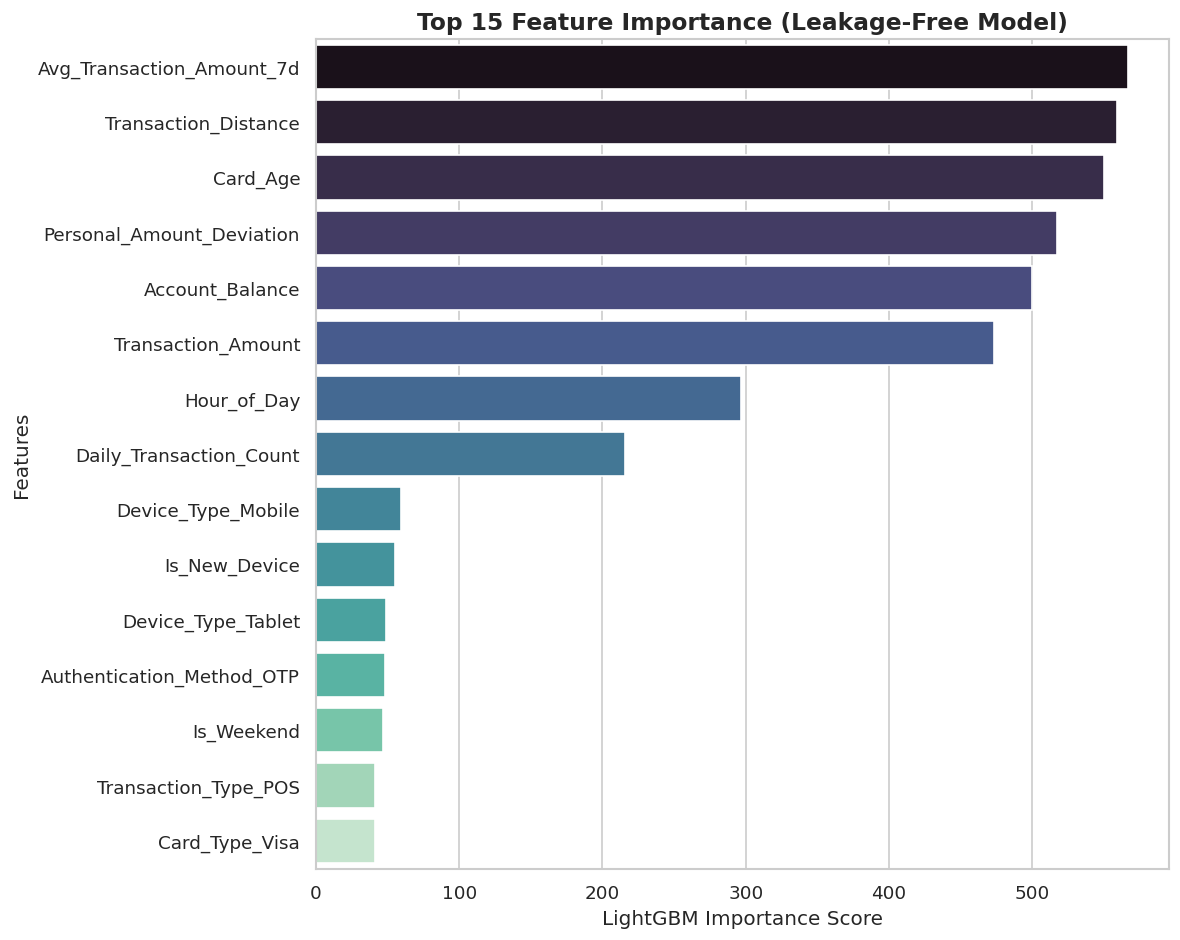

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, f1_score, classification_report
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. 누수 변수(Leakage) 및 임시 계산용 변수 완전 삭제
# =====================================================================
# 🚨 멘토님 지적사항 반영: 정답지(Risk_Score)와 미래정보(Failed_Count_7d) 제외
leakage_and_temp_cols = [
    'Transaction_ID', 'User_ID', 'Timestamp',
    'Risk_Score', 'Failed_Transaction_Count_7d',  # <--- 완벽히 삭제
    'Prev_Timestamp', 'Prev_Location', 'Time_Diff_Hours',
    'User_CumSum_Amount', 'User_Txn_Count', 'User_Historical_Avg',
    'Prev_Device', 'Context_Risk_Score'
]

# 위 컬럼들을 데이터셋에서 드롭 (에러 방지를 위해 errors='ignore' 추가)
df_clean = df.drop(columns=leakage_and_temp_cols, errors='ignore')

# =====================================================================
# 2. 데이터 전처리 (원-핫 인코딩 및 데이터 분할)
# =====================================================================
# 범주형 컬럼 인코딩 (True/False 대신 1/0 숫자로 변환)
cat_cols = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)

# 모델에 들어갈 문제(X)와 정답(y) 분리
X = df_encoded.drop(columns=['Fraud_Label'])
y = df_encoded['Fraud_Label']

# Train / Test 분할 (8:2 비율, 클래스 비율 유지 stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =====================================================================
# 3. 모델 학습 (LightGBM)
# =====================================================================
# 트리 앙상블 기반 LightGBM 모델 선언 (클래스 불균형을 고려해 class_weight='balanced' 적용)
print("🚀 LightGBM 모델 학습을 시작합니다 (데이터 누수 제거 완료)...")
lgb_model = lgb.LGBMClassifier(n_estimators=150, max_depth=7, random_state=42, class_weight='balanced')
lgb_model.fit(X_train, y_train)

# =====================================================================
# 4. 모델 평가 (멘토님 지정 지표: PRC-AUC, F1-Score)
# =====================================================================
y_pred = lgb_model.predict(X_test)
y_prob = lgb_model.predict_proba(X_test)[:, 1]

# PRC-AUC 계산
precision, recall, _ = precision_recall_curve(y_test, y_prob)
prc_auc = auc(recall, precision)

# F1-Score 계산
f1 = f1_score(y_test, y_pred)

print("\n" + "="*40)
print(f"🎯 [최종 평가 지표]")
print(f"✅ PRC-AUC Score: {prc_auc:.4f}")
print(f"✅ F1-Score     : {f1:.4f}")
print("="*40)
print("\n[분류 상세 리포트]")
print(classification_report(y_test, y_pred))

# =====================================================================
# 5. 변수 중요도 (Feature Importance) 시각화 - 우리가 만든 변수가 일하는지 확인!
# =====================================================================
feature_imp = pd.DataFrame(sorted(zip(lgb_model.feature_importances_, X.columns)), columns=['Value','Feature'])

# 스타일 및 폰트 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8), dpi=120)

# 상위 15개 중요 변수 출력
top_features = feature_imp.sort_values(by="Value", ascending=False).head(15)
sns.barplot(x="Value", y="Feature", data=top_features, palette='mako')

plt.title('Top 15 Feature Importance (Leakage-Free Model)', fontweight='bold', fontsize=14)
plt.xlabel('LightGBM Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()